In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
N_GIORNI = 365
PREZZO_INIZIALE = 50 #euro
#Media e deviazione standard dettano il "Destino" del grafico
variazioni_prezzo = np.random.normal(0.5, 5, N_GIORNI) #Normal fa valori per curva gaussiana
#Il primo parametro np.random.normal(valore medio, deviazione standard, shape array), più è grande la deviazione standard
#più il valore può variare, si chiama anche volatilità
variazioni_prezzo

array([ -5.55367148,  -6.01402633,  -1.05562516,   4.90727934,
         6.53414236,   4.30618378,   8.75604499,   1.95263413,
         4.49468115,   1.08343206,   3.38149079,   2.28901073,
         1.27422442,  -3.98040554,  -2.95644963,   2.85826074,
        -5.14901503,  -2.29232231,  -6.09379262,   7.55887624,
        -1.22867414,  -5.83391421,  -2.93761547, -18.14174741,
        -1.56232633,   0.71722378,   5.68697064,  -1.955466  ,
        -1.54428308,  -3.5307544 ,   0.55468116,   1.01622164,
         5.60519416, -14.80219598,  -4.58052561,   1.22637982,
        -1.03060629,   3.92305629,  -0.32428507,  -5.78825468,
         1.51537281,   5.5051535 ,  -2.70328092,   4.14705502,
         2.76952223,  11.78250105,  -9.76868923,   1.42859586,
        -0.34398944,  -0.68672007, -12.32488094,   6.33696566,
        -1.60174043,  -1.5878125 ,  15.11529576,   5.23227044,
         1.20942366,   4.31574548,   5.9769871 ,   2.30872903,
         0.03378099,   1.59423301,   1.6505396 ,  12.08

In [8]:
#somma cumulativa
prezzo = PREZZO_INIZIALE + np.cumsum(variazioni_prezzo)
prezzo

array([ 44.44632852,  38.4323022 ,  37.37667704,  42.28395638,
        48.81809874,  53.12428252,  61.88032751,  63.83296164,
        68.32764279,  69.41107485,  72.79256563,  75.08157636,
        76.35580079,  72.37539525,  69.41894562,  72.27720636,
        67.12819133,  64.83586902,  58.74207639,  66.30095263,
        65.07227849,  59.23836428,  56.30074881,  38.1590014 ,
        36.59667507,  37.31389885,  43.00086949,  41.04540349,
        39.50112042,  35.97036602,  36.52504718,  37.54126882,
        43.14646298,  28.34426701,  23.7637414 ,  24.99012123,
        23.95951494,  27.88257123,  27.55828616,  21.77003148,
        23.28540429,  28.7905578 ,  26.08727687,  30.2343319 ,
        33.00385413,  44.78635518,  35.01766595,  36.44626181,
        36.10227237,  35.4155523 ,  23.09067135,  29.42763701,
        27.82589659,  26.23808409,  41.35337985,  46.58565029,
        47.79507395,  52.11081943,  58.08780653,  60.39653555,
        60.43031654,  62.02454955,  63.67508914,  75.75

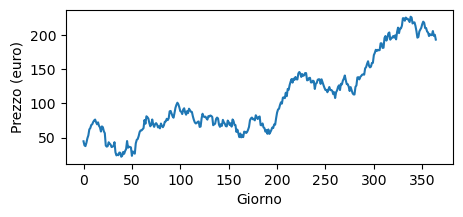

In [9]:
fig, ax = plt.subplots(figsize = (5, 2))
ax.plot(prezzo)
ax.set_xlabel("Giorno")
ax.set_ylabel("Prezzo (euro)")
plt.show()

In [10]:
variazioni_prezzo_calmierate = variazioni_prezzo.copy()
variazioni_prezzo_calmierate[variazioni_prezzo > 10] = 10
variazioni_prezzo_calmierate[variazioni_prezzo < -10] = -10

In [11]:
prezzo_calmierato = PREZZO_INIZIALE + np.cumsum(variazioni_prezzo_calmierate)

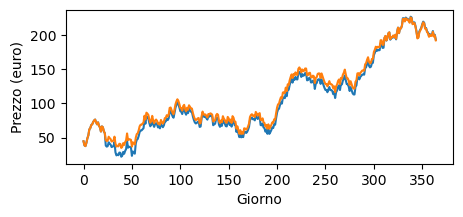

In [12]:
fig, ax = plt.subplots(figsize = (5, 2))
ax.plot(prezzo)
ax.plot(prezzo_calmierato)
ax.set_xlabel("Giorno")
ax.set_ylabel("Prezzo (euro)")
plt.show()

In [13]:
# Trovare minimi e massimi locali del prezzo calmierato con roll

In [14]:
precedente = np.roll(prezzo_calmierato, 1)
successivo = np.roll(prezzo_calmierato, -1)
#print(prezzo_calmierato)
#print(precedente)
#print(successivo)

massimi_locali = (prezzo_calmierato > precedente) & (prezzo_calmierato > successivo)
massimi_locali[0] = False
massimi_locali[-1] = False
istanti_massimi_locali = prezzo_calmierato[massimi_locali]
print(istanti_massimi_locali)

minimi_locali = (prezzo_calmierato < precedente) & (prezzo_calmierato < successivo)
minimi_locali[0] = False
minimi_locali[-1] = False
istanti_minimi_locali = prezzo_calmierato[minimi_locali]
print(istanti_minimi_locali)

[ 76.35580079  72.27720636  66.30095263  51.1426169   51.28821039
  37.93406461  40.82651461  41.73450118  55.94779751  47.60770414
  42.91396029  82.04611666  86.47073896  81.79934161  76.42035156
  71.55877972  75.80909145  82.76070571  94.1061054  106.15040061
  97.98077228  93.74987639  97.34948025  78.64390854  88.09293213
  83.86692754  84.54789673  85.51676191  84.66421632  75.02056214
  81.3185523   80.2780856   76.28623702  81.37282638  66.4945173
  60.77841632  58.03012894  63.50909818  84.2274694   82.36159785
  87.59019599  85.81975934  78.16297059  68.51684811  69.36352531
  72.10930859  76.7708689  109.18913156 116.55714692 123.30794482
 128.14692515 142.65860185 143.25954114 145.65855309 152.9440603
 149.93260542 151.41807407 145.1141156  140.90103275 144.20483248
 144.11407704 128.54678583 132.7980267  128.30971745 125.17348593
 135.27000372 137.53846218 149.7561698  132.691168   144.52903364
 148.62576419 167.9123083  183.36450558 183.29852214 192.88888811
 199.2728213

## ex 10 pag 106-107

In [7]:
import numpy as np
ERRORE = 9999.9

N_CAMPIONI = 1000 #Campo continuo per come vengono rappresentati
VALORE_MEDIO = 19.0
VARIANZA = 5.0

N_ERRORI = 20

#Se tiro due dadi ho valori nel discreto, (Interi) avrò 2, 3...4..Nel campo continuo posso avere qualsiasi valore

In [8]:
misure = np.random.normal(VALORE_MEDIO, np.sqrt(VARIANZA), N_CAMPIONI)  
#Normal prende dati per una curva gaussiana
#Se metto un punto di domanda dopo un comando vedo cosa fa, oppure uso help(Funzione)
#La varianza è la deviazione alla seconda, quindi la deviazione è la radice della varianza

In [9]:
indici = np.random.randint(0, N_CAMPIONI, N_ERRORI) #Può avere doppioni

In [10]:
indici = np.random.choice(np.arange(0, N_CAMPIONI), N_ERRORI, replace=False) #Passandogli false lui non ti fa comparire numeri uguali

In [11]:
misure[indici] = ERRORE

In [12]:
np.mean(misure) #La media è sfasata per colpa degli errori

np.float64(218.68075193792924)

In [13]:
ROWS = 6
matrix = np.zeros((ROWS, N_CAMPIONI), dtype = np.bool)
for i in range(ROWS): #è andato a destra di 1, array dei precedenti
    matrix[i] = np.roll(misure, i) == ERRORE #Cerca dov'è 9, quando becco due o più true nella stessa colonna allora!!
matrix

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [14]:
np.any(np.count_nonzero(matrix, axis = 0) >= 2) #Così abbiamo le colonne dove effetivamente questo succede

np.True_

In [15]:
indici_errori = misure == True

In [16]:
misure_ripulito = misure != ERRORE
#misure[misure_ripulito]

In [17]:
np.mean(misure)

np.float64(218.68075193792924)

In [18]:
np.min(misure)

np.float64(11.463751088452282)

In [19]:
np.max(misure)

np.float64(9999.9)

In [20]:
#Calcoliamo lo scarto quadratico, la varianza
np.var(misure)

np.float64(1952499.6873317424)

## ex 4 pag 107

Paradosso del compleanno, abbastanza comune..50% di probabilità su 23 alunni, devo simulare una data di nascita a caso 
con un numero tra 1 a 365 (Attenzione al bisestile)

In [69]:
import numpy as np
import matplotlib.pyplot as plt
CLASSI = 1000
ALUNNI = 25
N_GIORNI = 366

nascite = np.random.randint(1, N_GIORNI, (CLASSI, ALUNNI)) #Può avere doppioni
nascite

array([[347, 276, 270, ..., 245, 364, 307],
       [  9, 106, 130, ..., 132, 174, 218],
       [346, 180,  23, ..., 210, 358, 127],
       ...,
       [347, 196, 139, ..., 359, 228, 100],
       [308, 276,  82, ..., 252, 234, 239],
       [167, 260,  96, ..., 275,  82, 250]], dtype=int32)

In [70]:
duplicati = np.array([len(np.unique(c)) < ALUNNI for c in nascite]) #ridà vettori senza duplicati lo unique

In [71]:
n_classi_Compleanni_uguali = np.sum(duplicati)
n_classi_Compleanni_uguali

np.int64(593)

In [72]:
def probabilitaCompleanniDuplicati(ALUNNI, CLASSI = 1000):
    nascite = np.random.randint(1, N_GIORNI, (CLASSI, ALUNNI)) #Può avere doppioni
    duplicati = np.array([len(np.unique(c)) < ALUNNI for c in nascite]) #ridà vettori senza duplicati lo unique
    return np.sum(duplicati) / CLASSI

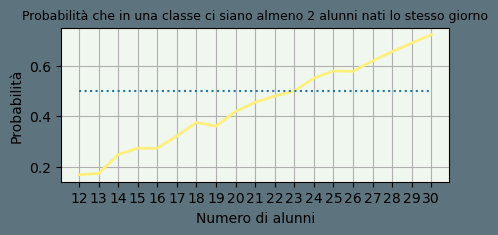

In [91]:
array_n_alunni = np.arange(12, 31)
probabilita = np.array([probabilitaCompleanniDuplicati(n) for n in array_n_alunni])
fig, ax = plt.subplots(figsize = (5, 2))
ax.set_facecolor("#F0F7EE")
fig.set_facecolor("#5D737E")
ax.plot(array_n_alunni, probabilita, color="#FFF07C", linewidth=2)
ax.set_xlabel("Numero di alunni")
ax.set_ylabel("Probabilità")
ax.set_title("Probabilità che in una classe ci siano almeno 2 alunni nati lo stesso giorno",
            fontsize = 9)
ax.grid()
ax.set_xticks(array_n_alunni) #Per la griglia, i cubetti
ax.hlines(0.5, 12, 30, linestyle = "dotted")
plt.show()

## EX 11 P 107

In [11]:
ERRORE_1 = 9999.9
ERRORE_2 = -1.
PROB_1 = 0.002
PROB_2 = 0.001

COLONNE = 3
DATI_MINUTI = 1440

In [12]:
misure = np.random.normal(19, np.sqrt(5), (1440, 3))
misure

array([[17.58001794, 17.83505659, 15.92562304],
       [22.37675724, 22.49958636, 18.99756899],
       [16.79852608, 18.65487534, 17.56536695],
       ...,
       [18.44674202, 23.78557799, 24.83827772],
       [18.79783461, 20.77810665, 19.28211165],
       [18.40738949, 20.26238666, 17.88374583]])

In [20]:
errore_1 = np.random.choice([False, True], size=(1440, 3), p=[1-PROB_1, PROB_1]) #Maschera di True e false
misure[errore_1] = ERRORE_1

In [21]:
errore_2 = np.random.choice([False, True], size=(1440, 3), p=[1-PROB_2, PROB_2]) #Maschera di True e false
misure[errore_2] = ERRORE_2

In [22]:
misura_errata = misure == ERRORE_1
misura_sconosciuta = misure == ERRORE_2

In [36]:
misure_da_rimuovere = (misura_errata) | (misura_sconosciuta)

In [37]:
righe_ok = np.logical_not(np.any(misure_da_rimuovere, axis = 1)) #Sulle righe cerchiamo quelle con almeno una misurazione errata

In [41]:
dati_ok = misure[righe_ok] #Prende solo i true in questo caso
dati_ok

array([[22.37675724, 22.49958636, 18.99756899],
       [16.79852608, 18.65487534, 17.56536695],
       [20.33788761, 16.54885197, 18.45303126],
       ...,
       [18.44674202, 23.78557799, 24.83827772],
       [18.79783461, 20.77810665, 19.28211165],
       [18.40738949, 20.26238666, 17.88374583]])

In [42]:
dati_ok.shape

(1419, 3)